# Lab 3 

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model


## 2. Load and Prepare Data


In [2]:
IMAGE_SIZE = (128, 128)
NUM_IMAGES = 2000


base_path = "archive/Infection Segmentation Data/Infection Segmentation Data"
train_img_dir = os.path.join(base_path, "Train/COVID-19/images")
train_mask_dir = os.path.join(base_path, "Train/COVID-19/infection masks")
val_img_dir = os.path.join(base_path, "Val/COVID-19/images")
val_mask_dir = os.path.join(base_path, "Val/COVID-19/infection masks")

def load_images_and_masks(img_folder, mask_folder, limit):
    images = []
    masks = []
    
    files = sorted(os.listdir(img_folder))
    
    for filename in files:
        if len(images) >= limit:
            break
            
        # Construct full paths
        img_path = os.path.join(img_folder, filename)
        mask_path = os.path.join(mask_folder, filename)
        
        if os.path.exists(mask_path):
        
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, IMAGE_SIZE)
            img = img / 255.0               # Normalize to 0-1
            img = np.expand_dims(img, axis=-1) # Add channel dim: (128,128,1)
            
        
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, IMAGE_SIZE)
            mask = mask / 255.0             # Normalize to 0-1
            mask = (mask > 0.5).astype(np.float32) # Convert to strict 0 or 1
            mask = np.expand_dims(mask, axis=-1)
            
            images.append(img)
            masks.append(mask)
            
    return images, masks

X, y = load_images_and_masks(train_img_dir, train_mask_dir, NUM_IMAGES)

if len(X) < NUM_IMAGES:
    more_X, more_y = load_images_and_masks(val_img_dir, val_mask_dir, NUM_IMAGES - len(X))
    X.extend(more_X)
    y.extend(more_y)

X = np.array(X)
y = np.array(y)

print(f" Loaded {len(X)} images.")
print(f"Image Shape: {X.shape}, Mask Shape: {y.shape}")

 Loaded 2000 images.
Image Shape: (2000, 128, 128, 1), Mask Shape: (2000, 128, 128, 1)


## 3. Train / Validation Split

In [3]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 1600
Validation samples: 400


## 4. Build Simple U-Net Model


In [4]:
def simple_unet_model(input_size=(128, 128, 1)):
    inputs = Input(input_size)
    
    # Helper to clean up code
    def conv_block(x, filters):
        x = Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = Conv2D(filters, 3, activation='relu', padding='same')(x)
        return x

    # --- Encoder ---
    c1 = conv_block(inputs, 32)
    p1 = MaxPooling2D()(c1)
    
    c2 = conv_block(p1, 64)
    p2 = MaxPooling2D()(c2)
    
    # --- Bottom ---
    c3 = conv_block(p2, 128)
    
    # --- Decoder ---
    u4 = UpSampling2D()(c3)
    u4 = Concatenate()([u4, c2])
    c4 = conv_block(u4, 64)
    
    u5 = UpSampling2D()(c4)
    u5 = Concatenate()([u5, c1])
    c5 = conv_block(u5, 32)
    
    # Output
    outputs = Conv2D(1, 1, activation='sigmoid')(c5)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = simple_unet_model()
# model.summary() # Table removed for brevity

## 5. Train the Model

In [5]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=15,
    verbose=1
)

Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 4181s 85s/step - accuracy: 0.7926 - loss: 0.4774 - val_accuracy: 0.8618 - val_loss: 0.3346
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - accuracy: 0.8558 - loss: 0.3367 - val_accuracy: 0.8618 - val_loss: 0.3115
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - accuracy: 0.8580 - loss: 0.3159 - val_accuracy: 0.8618 - val_loss: 0.2913
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 996s 20s/step - accuracy: 0.8612 - loss: 0.2824 - val_accuracy: 0.8779 - val_loss: 0.2538
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.8789 - loss: 0.2612 - val_accuracy: 0.8911 - val_loss: 0.2397
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 915s 19s/step - accuracy: 0.8855 - loss: 0.2495 - val_accuracy: 0.8929 - val_loss: 0.2351
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.8932 - loss: 0.2308 - val_accuracy: 0.8950 - val_loss: 0.2337
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6079s 124s/step - accuracy: 0.8978 - loss: 0.2255 - val_accuracy: 0.9

## 6. Results and Visualization

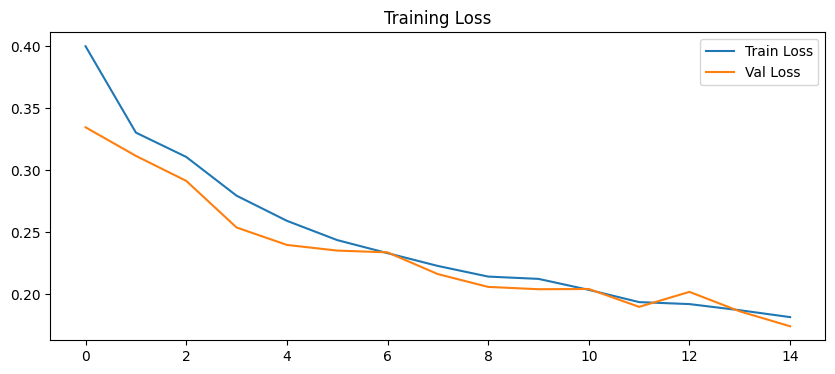

In [ ]:

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step


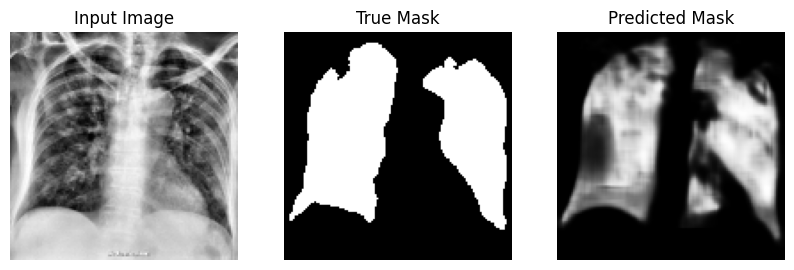

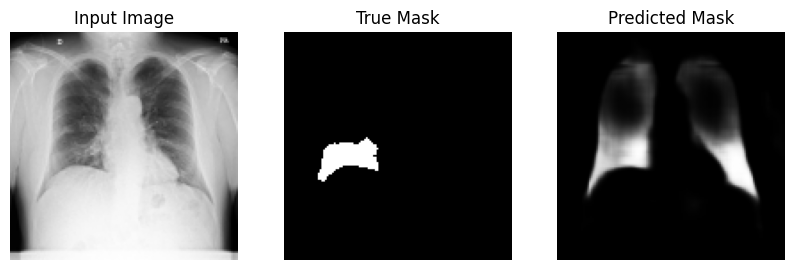

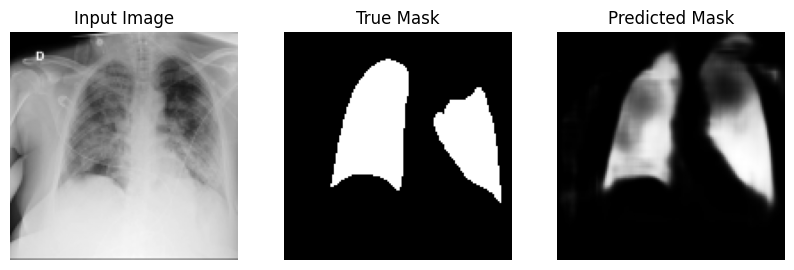

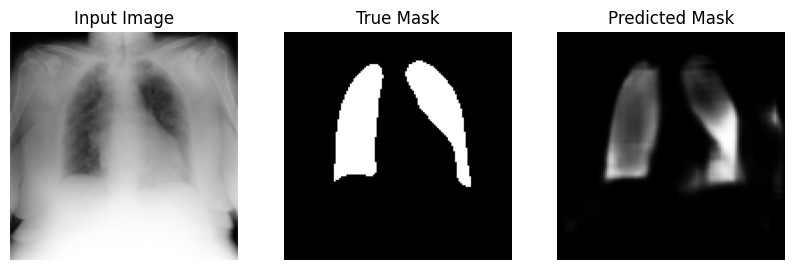

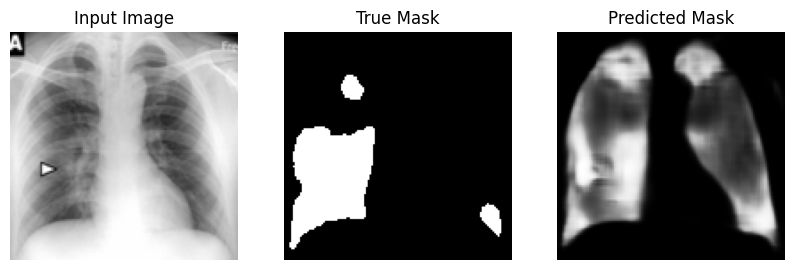

In [7]:
# Visualize Predictions
predictions = model.predict(X_val[:5])

for i in range(len(predictions)):
    plt.figure(figsize=(10, 3))
    
    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(X_val[i].reshape(128, 128), cmap='gray')
    plt.title('Input Image')
    plt.axis('off')
    
    # Mask (Ground Truth)
    plt.subplot(1, 3, 2)
    plt.imshow(y_val[i].reshape(128, 128), cmap='gray')
    plt.title('True Mask')
    plt.axis('off')
    
    # Predicted
    plt.subplot(1, 3, 3)
    plt.imshow(predictions[i].reshape(128, 128), cmap='gray')
    plt.title('Predicted Mask')
    plt.axis('off')
    
    plt.show()